# Calibrating and Time Binning Astronomical Data

**UPDATE 14.08**: We have updated the calibration steps in the notebook. We understand that some of you have been using the old calibration procedure. The old procedures still provide a good estimate of the transit depth over different wavelengths, but as competition hosts we understand the difficulty to accurately calibrate the data product (even for us, it is still a learning journey, afterall, we are preparing for the mission), and we want to make sure you have the most updated knowledge on the calibration pipeline, so that it helps your journey in tackling this challenge. We will explain more in our discussion 

Data reduction is crucial in astronomical observations, and this challenge is no exception. This notebook outlines essential calibration steps typically employed by astronomers to mitigate noise in data.

Key points:

- The notebook guides participants through pre-processing data and saving it in a more convenient, lighter format.
- If you plan to use the baseline models (which will be released soon), you must run this notebook first before training.

Important note: While these steps help reduce noise and data size, they may not be the most effective approach for achieving the optimal model for this challenge. Participants are encouraged to explore alternative methods that could yield better results.





**Acknowledgement**: This notebook is prepared by Angèle Syty and Virginie Batista (IAP), with support from Andrea Bocchieri, Orphée Faucoz (CNES), Lorenzo V. Mugnai (Cardiff University & UCL), Tara Tahseen (UCL), Gordon Yip (UCL).

Last modified: 14 Aug 2024. 

In [1]:
import numpy as np
import pandas as pd
import itertools
import os
import glob 
from astropy.stats import sigma_clip

from tqdm import tqdm

### Define the GLL metric score for training

In [3]:
import pandas.api.types
import scipy.stats


class ParticipantVisibleError(Exception):
    pass


def score(
        solution: pd.DataFrame,
        submission: pd.DataFrame,
        row_id_column_name: str,
        naive_mean: float,
        naive_sigma: float,
        sigma_true: float
    ) -> float:
    '''
    This is a Gaussian Log Likelihood based metric. For a submission, which contains the predicted mean (x_hat) and variance (x_hat_std),
    we calculate the Gaussian Log-likelihood (GLL) value to the provided ground truth (x). We treat each pair of x_hat,
    x_hat_std as a 1D gaussian, meaning there will be 283 1D gaussian distributions, hence 283 values for each test spectrum,
    the GLL value for one spectrum is the sum of all of them.

    Inputs:
        - solution: Ground Truth spectra (from test set)
            - shape: (nsamples, n_wavelengths)
        - submission: Predicted spectra and errors (from participants)
            - shape: (nsamples, n_wavelengths*2)
        naive_mean: (float) mean from the train set.
        naive_sigma: (float) standard deviation from the train set.
        sigma_true: (float) essentially sets the scale of the outputs.
    '''

    del solution[row_id_column_name]
    del submission[row_id_column_name]

    if submission.min().min() < 0:
        raise ParticipantVisibleError('Negative values in the submission')
    for col in submission.columns:
        if not pandas.api.types.is_numeric_dtype(submission[col]):
            raise ParticipantVisibleError(f'Submission column {col} must be a number')

    n_wavelengths = len(solution.columns)
    if len(submission.columns) != n_wavelengths*2:
        raise ParticipantVisibleError('Wrong number of columns in the submission')

    y_pred = submission.iloc[:, :n_wavelengths].values
    # Set a non-zero minimum sigma pred to prevent division by zero errors.
    sigma_pred = np.clip(submission.iloc[:, n_wavelengths:].values, a_min=10**-15, a_max=None)
    y_true = solution.values

    GLL_pred = np.sum(scipy.stats.norm.logpdf(y_true, loc=y_pred, scale=sigma_pred))
    GLL_true = np.sum(scipy.stats.norm.logpdf(y_true, loc=y_true, scale=sigma_true * np.ones_like(y_true)))
    GLL_mean = np.sum(scipy.stats.norm.logpdf(y_true, loc=naive_mean * np.ones_like(y_true), scale=naive_sigma * np.ones_like(y_true)))

    submit_score = (GLL_pred - GLL_mean)/(GLL_true - GLL_mean)
    return float(np.clip(submit_score, 0.0, 1.0))

Below, we define the corrections we want to apply, the size of the data chunks and the different path used to import data and save the light ones. 

In [4]:

path_folder = '/kaggle/input/ariel-data-challenge-2024/' # path to the folder containing the data
path_out = '/kaggle/tmp/data_light_raw/' # path to the folder to store the light data
output_dir = '/kaggle/tmp/data_light_raw/' # path for the output directory


If the *path_out* folder doesn't exist yet, it is created. 

In [5]:
if not os.path.exists(path_out):
    os.makedirs(path_out)
    print(f"Directory {path_out} created.")
else:
    print(f"Directory {path_out} already exists.")


Directory /kaggle/tmp/data_light_raw/ created.


**Data import:**

 The files are imported by chunks of size 'CHUNK_SIZE' to avoid exceeding the memory capacity. 

In [6]:
CHUNKS_SIZE = 6 ## for this demo, it must be divisible by 672 (N Training data )

## Step 1: Analog-to-Digital Conversion

The Analog-to-Digital Conversion (adc) is performed by the detector to convert the pixel voltage into an integer number. We revert this operation by using the gain and offset for the calibration files 'train_adc_info.csv'.


In [7]:
def ADC_convert(signal, gain, offset):
    signal = signal.astype(np.float64)
    signal /= gain
    signal += offset
    return signal

## Step 2: Mask hot/dead pixel
The dead pixels map is a map of the pixels that do not respond to light and, thus, can’t be accounted for any calculation. In all these frames the dead pixels are masked using python masked arrays. The bad pixels are thus masked but left uncorrected. Some methods can be used to correct bad-pixels but this task, if needed, is left to the participants.

In [8]:
def mask_hot_dead(signal, dead, dark):
    hot = sigma_clip(
        dark, sigma=5, maxiters=5
    ).mask
    hot = np.tile(hot, (signal.shape[0], 1, 1))
    dead = np.tile(dead, (signal.shape[0], 1, 1))
    signal = np.ma.masked_where(dead, signal)
    signal = np.ma.masked_where(hot, signal)
    return signal

## Step 2: linearity Correction



**Non-linearity of pixels' response:**

The non-linearity of the pixels’ response can be explained as capacitive leakage on the readout electronics of each pixel during the integration time. The number of electrons in the well is proportional to the number of photons that hit the pixel, with a quantum efficiency coefficient. However, the response of the pixel is not linear with the number of electrons in the well. This effect can be described by a polynomial function of the number of electrons actually in the well. The data is provided with calibration files linear_corr.parquet that are the coefficients of the inverse polynomial function and can be used to correct this non-linearity effect.



In [9]:
def apply_linear_corr(linear_corr,clean_signal):
    linear_corr = np.flip(linear_corr, axis=0)
    for x, y in itertools.product(
                range(clean_signal.shape[1]), range(clean_signal.shape[2])
            ):
        poli = np.poly1d(linear_corr[:, x, y])
        clean_signal[:, x, y] = poli(clean_signal[:, x, y])
    return clean_signal
    

## Step 3: dark current subtraction

The data provided include calibration for dark current estimation, which can be used to pre-process the observations. Dark current represents a constant signal that accumulates in each pixel during the integration time, independent of the incoming light. To obtain the corrected image, the following conventional approach is applied: The data provided include calibration files such as dark frames or dead pixels' maps. They can be used to pre-process the observations. The dark frame is a map of the detector response to a very short exposure time, to correct for the dark current of the detector.
$$\text{image - dark} \times \Delta t $$ 
The corrected image is conventionally obtained via the following: where the dark current map is first corrected for the dead pixel.

In [10]:
def clean_dark(signal, dead, dark, dt):

    dark = np.ma.masked_where(dead, dark)
    dark = np.tile(dark, (signal.shape[0], 1, 1))

    signal -= dark* dt[:, np.newaxis, np.newaxis]
    return signal


## Step 4: Get Correlated Double Sampling (CDS)

The science frames are alternating between the start of the exposure and the end of the exposure. The lecture scheme is a ramp with a double sampling, called Correlated Double Sampling (CDS), the detector is read twice, once at the start of the exposure and once at the end of the exposure. The final CDS is the difference (End of exposure) - (Start of exposure).

In [11]:
def get_cds(signal):
    cds = signal[:,1::2,:,:] - signal[:,::2,:,:]
    return cds

## Step 5 (Optional): Time Binning
This step is performed mianly to save space. Time series observations are binned together at specified frequency. 



In [12]:
def bin_obs(cds_signal,binning):
    cds_transposed = cds_signal.transpose(0,1,3,2)
    cds_binned = np.zeros((cds_transposed.shape[0], cds_transposed.shape[1]//binning, cds_transposed.shape[2], cds_transposed.shape[3]))
    for i in range(cds_transposed.shape[1]//binning):
        cds_binned[:,i,:,:] = np.sum(cds_transposed[:,i*binning:(i+1)*binning,:,:], axis=1)
    return cds_binned

## Step 6: Flat Field Correction


The flat field is a map of the detector response to uniform illumination, to correct for the pixel-to-pixel variations of the detector, for example the different quantum efficiencies of each pixel.

In [13]:
def correct_flat_field(flat,dead, signal):
    flat = flat.transpose(1, 0)
    dead = dead.transpose(1, 0)
    flat = np.ma.masked_where(dead, flat)
    flat = np.tile(flat, (signal.shape[0], 1, 1))
    signal = signal / flat
    return signal

# Calibrating all training data

you can choose to correct the non-linearity of the pixels' response, to apply flat field, dark and dead map or to leave the data unchanged. The observations are binned in time by group of 30 frames for AIRS and 360 frames for FGS1, to obtain a lighter data-cube, easier to use. The images are cut along the wavelength axis between pixels 39 and 321, so that the 282 pixels left in the wavelength dimension match the last 282 targets' points, from AIRS. The 283rd targets' point is the one for FGS1 that will be added later on. 

In [14]:
## we will start by getting the index of the training data:
def get_index(files,CHUNKS_SIZE ):
    index = []
    for file in files :
        file_name = file.split('/')[-1]
        if file_name.split('_')[0] == 'AIRS-CH0' and file_name.split('_')[1] == 'signal.parquet':
            file_index = os.path.basename(os.path.dirname(file))
            index.append(int(file_index))
    index = np.array(index)
    index = np.sort(index) 
    index = index.reshape(-1, CHUNKS_SIZE)
    
    return index

In [15]:
files = glob.glob(os.path.join(path_folder + 'train/', '*/*'))

index = get_index(files[:22],CHUNKS_SIZE)  ## 48 is hardcoded here but please feel free to remove it if you want to do it for the entire dataset

train_adc_info = pd.read_csv(os.path.join(path_folder, 'train_adc_info.csv'))
train_adc_info = train_adc_info.set_index('planet_id')
axis_info = pd.read_parquet(os.path.join(path_folder,'axis_info.parquet'))
DO_MASK = True
DO_THE_NL_CORR = False
DO_DARK = True
DO_FLAT = True
TIME_BINNING = True

N = index.shape[0]
cut_inf, cut_sup = 39, 321
l = cut_sup - cut_inf

for n, index_chunk in tqdm(enumerate(index)):
    AIRS_CH0_clean = np.zeros((CHUNKS_SIZE, 11250, 32, l))
    FGS1_clean = np.zeros((CHUNKS_SIZE, 135000, 32, 32))
    
    for i in range (CHUNKS_SIZE) : 
        df = pd.read_parquet(os.path.join(path_folder,f'train/{index_chunk[i]}/AIRS-CH0_signal.parquet'))
        signal = df.values.astype(np.float64).reshape((df.shape[0], 32, 356))
        gain = train_adc_info['AIRS-CH0_adc_gain'].loc[index_chunk[i]]
        offset = train_adc_info['AIRS-CH0_adc_offset'].loc[index_chunk[i]]
        signal = ADC_convert(signal, gain, offset)
        dt_airs = axis_info['AIRS-CH0-integration_time'].dropna().values
        chopped_signal = signal[:, :, cut_inf:cut_sup]
        del signal, df
        
        # CLEANING THE DATA: AIRS
        flat = pd.read_parquet(os.path.join(path_folder,f'train/{index_chunk[i]}/AIRS-CH0_calibration/flat.parquet')).values.astype(np.float64).reshape((32, 356))[:, cut_inf:cut_sup]
        dark = pd.read_parquet(os.path.join(path_folder,f'train/{index_chunk[i]}/AIRS-CH0_calibration/dark.parquet')).values.astype(np.float64).reshape((32, 356))[:, cut_inf:cut_sup]
        dead_airs = pd.read_parquet(os.path.join(path_folder,f'train/{index_chunk[i]}/AIRS-CH0_calibration/dead.parquet')).values.astype(np.float64).reshape((32, 356))[:, cut_inf:cut_sup]
        linear_corr = pd.read_parquet(os.path.join(path_folder,f'train/{index_chunk[i]}/AIRS-CH0_calibration/linear_corr.parquet')).values.astype(np.float64).reshape((6, 32, 356))[:, :, cut_inf:cut_sup]
        
        if DO_MASK:
            chopped_signal = mask_hot_dead(chopped_signal, dead_airs, dark)
            AIRS_CH0_clean[i] = chopped_signal
        else:
            AIRS_CH0_clean[i] = chopped_signal
            
        if DO_THE_NL_CORR: 
            linear_corr_signal = apply_linear_corr(linear_corr,AIRS_CH0_clean[i])
            AIRS_CH0_clean[i,:, :, :] = linear_corr_signal
        del linear_corr
        
        if DO_DARK: 
            cleaned_signal = clean_dark(AIRS_CH0_clean[i], dead_airs, dark, dt_airs)
            AIRS_CH0_clean[i] = cleaned_signal
        else: 
            pass
        del dark
        
        df = pd.read_parquet(os.path.join(path_folder,f'train/{index_chunk[i]}/FGS1_signal.parquet'))
        fgs_signal = df.values.astype(np.float64).reshape((df.shape[0], 32, 32))
        
        FGS1_gain = train_adc_info['FGS1_adc_gain'].loc[index_chunk[i]]
        FGS1_offset = train_adc_info['FGS1_adc_offset'].loc[index_chunk[i]]
        
        fgs_signal = ADC_convert(fgs_signal, FGS1_gain, FGS1_offset)
        dt_fgs1 = np.ones(len(fgs_signal))*0.1
        chopped_FGS1 = fgs_signal
        del fgs_signal, df
        
        # CLEANING THE DATA: FGS1
        flat = pd.read_parquet(os.path.join(path_folder,f'train/{index_chunk[i]}/FGS1_calibration/flat.parquet')).values.astype(np.float64).reshape((32, 32))
        dark = pd.read_parquet(os.path.join(path_folder,f'train/{index_chunk[i]}/FGS1_calibration/dark.parquet')).values.astype(np.float64).reshape((32, 32))
        dead_fgs1 = pd.read_parquet(os.path.join(path_folder,f'train/{index_chunk[i]}/FGS1_calibration/dead.parquet')).values.astype(np.float64).reshape((32, 32))
        linear_corr = pd.read_parquet(os.path.join(path_folder,f'train/{index_chunk[i]}/FGS1_calibration/linear_corr.parquet')).values.astype(np.float64).reshape((6, 32, 32))
        
        if DO_MASK:
            chopped_FGS1 = mask_hot_dead(chopped_FGS1, dead_fgs1, dark)
            FGS1_clean[i] = chopped_FGS1
        else:
            FGS1_clean[i] = chopped_FGS1

        if DO_THE_NL_CORR: 
            linear_corr_signal = apply_linear_corr(linear_corr,FGS1_clean[i])
            FGS1_clean[i,:, :, :] = linear_corr_signal
        del linear_corr
        
        if DO_DARK: 
            cleaned_signal = clean_dark(FGS1_clean[i], dead_fgs1, dark,dt_fgs1)
            FGS1_clean[i] = cleaned_signal
        else: 
            pass
        del dark
        
    # SAVE DATA AND FREE SPACE
    AIRS_cds = get_cds(AIRS_CH0_clean)
    FGS1_cds = get_cds(FGS1_clean)
    
    del AIRS_CH0_clean, FGS1_clean
    
    ## (Optional) Time Binning to reduce space
    if TIME_BINNING:
        AIRS_cds_binned = bin_obs(AIRS_cds,binning=30)
        FGS1_cds_binned = bin_obs(FGS1_cds,binning=30*12)
    else:
        AIRS_cds = AIRS_cds.transpose(0,1,3,2) ## this is important to make it consistent for flat fielding, but you can always change it
        AIRS_cds_binned = AIRS_cds
        FGS1_cds = FGS1_cds.transpose(0,1,3,2)
        FGS1_cds_binned = FGS1_cds
    
    del AIRS_cds, FGS1_cds
    
    for i in range (CHUNKS_SIZE):
        flat_airs = pd.read_parquet(os.path.join(path_folder,f'train/{index_chunk[i]}/AIRS-CH0_calibration/flat.parquet')).values.astype(np.float64).reshape((32, 356))[:, cut_inf:cut_sup]
        flat_fgs = pd.read_parquet(os.path.join(path_folder,f'train/{index_chunk[i]}/FGS1_calibration/flat.parquet')).values.astype(np.float64).reshape((32, 32))
        if DO_FLAT:
            corrected_AIRS_cds_binned = correct_flat_field(flat_airs,dead_airs, AIRS_cds_binned[i])
            AIRS_cds_binned[i] = corrected_AIRS_cds_binned
            corrected_FGS1_cds_binned = correct_flat_field(flat_fgs,dead_fgs1, FGS1_cds_binned[i])
            FGS1_cds_binned[i] = corrected_FGS1_cds_binned
        else:
            pass

    ## save data
    np.save(os.path.join(path_out, 'AIRS_clean_train_{}.npy'.format(n)), AIRS_cds_binned)
    np.save(os.path.join(path_out, 'FGS1_train_{}.npy'.format(n)), FGS1_cds_binned)
    del AIRS_cds_binned
    del FGS1_cds_binned

1it [01:49, 109.57s/it]


### Once all the chunks are saved, we concatenate them back in a single dataset. This step is simply to save HDD space, modify it as you wish. 

In [16]:
def load_data (file, chunk_size, nb_files) : 
    data0 = np.load(file + '_0.npy')
    data_all = np.zeros((nb_files*chunk_size, data0.shape[1], data0.shape[2], data0.shape[3]))
    data_all[:chunk_size] = data0
    for i in range (1, nb_files) : 
        data_all[i*chunk_size:(i+1)*chunk_size] = np.load(file + '_{}.npy'.format(i))
    return data_all 

data_train = load_data(path_out + 'AIRS_clean_train', CHUNKS_SIZE, len(index)) 
data_train_FGS = load_data(path_out + 'FGS1_train', CHUNKS_SIZE, len(index))


In [17]:
np.save('/kaggle/working/' + 'data_train.npy', data_train)
np.save('/kaggle/working/' + 'data_train_FGS.npy', data_train_FGS)

# Plots

### Let us checks that everything went well during the data import. 

In [18]:
import matplotlib.pyplot as plt 

print('Shape of the training datasset: \t')
print('\n For AIRS-CH0:', data_train.shape)
print('\n For FGS1:', data_train_FGS.shape)

Shape of the training datasset: 	

 For AIRS-CH0: (6, 187, 282, 32)

 For FGS1: (6, 187, 32, 32)


### Plot of some images: 

In [19]:
data_train[-1,50,:,:].T.shape

(32, 282)

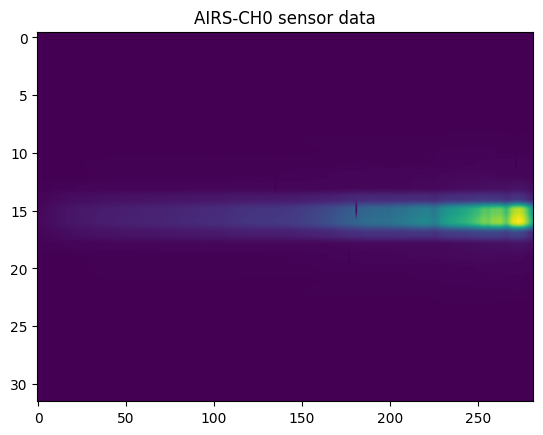

In [20]:
plt.imshow(data_train[-1,50,:,:].T, aspect = 'auto')
plt.title("AIRS-CH0 sensor data")
plt.show()

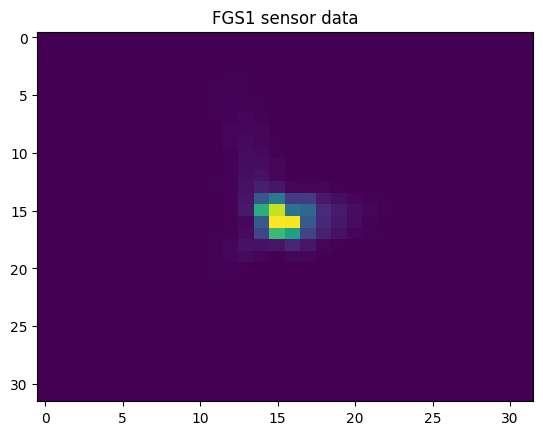

In [21]:
plt.imshow(data_train_FGS[-1,50,:,:].T, aspect = 'auto')
plt.title("FGS1 sensor data")
plt.show()

### Plot of some light-curves: 

In [22]:
import torch

In [23]:
data_train.shape

(6, 187, 282, 32)

### Refactoring light_curve tensor to (batch, n_mels, n_ctx)

In [26]:
light_curve_unshaped = data_train
light_curve_reshaped = data_train.reshape(6,187,-1) #data_train.mean(axis=(2,3))
light_curve_reshaped = torch.tensor(light_curve_reshaped/light_curve_reshaped.mean(axis=(0,1,2)), dtype=torch.float)
light_curve_reshaped.shape

torch.Size([6, 187, 9024])

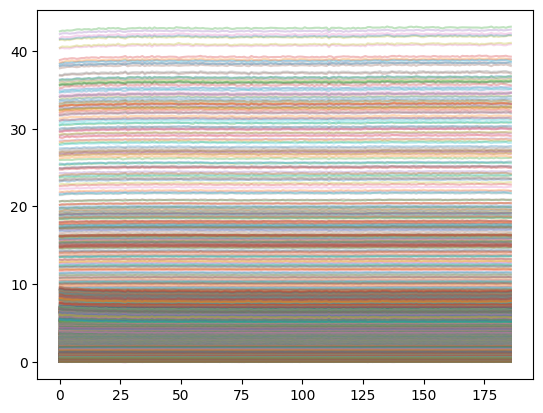

In [28]:
plt.plot(light_curve_reshaped[0,:,:], '-', alpha=0.3)
plt.show()

In [29]:
light_curve_unshaped.shape

(6, 187, 282, 32)

In [30]:
# light_curve_mean = []
# light_curve_unshaped = None

# for i in range(len(data_train)) : 
    
    
#     light_curve_unshaped = data_train[i,:,:,:]
#     print(data_train[i,:,:,:].shape)
#     light_curve_whisper = data_train[i,:,:,:].reshape(187, -1)
#     light_curve = data_train[i,:,:,:].sum(axis=(1,2))
#     light_curve_mean.append(light_curve/light_curve.mean())
#     plt.plot(light_curve/light_curve.mean(), '-', alpha=0.3)

# light_curve_mean = torch.tensor(light_curve_mean, dtype= torch.float)
    
# plt.xlabel('Time (frame index)')
# plt.ylabel('Normalized flux in the frame')
# plt.show()

In [31]:
# light_curve_mean.shape

# Feed data to pre-trained whisper model

In [32]:
! pip install git+https://github.com/openai/whisper.git
! pip install jiwer

  Cloning https://github.com/openai/whisper.git to /tmp/pip-req-build-bshdjptr
  Running command git clone --filter=blob:none --quiet https://github.com/openai/whisper.git /tmp/pip-req-build-bshdjptr
  Resolved https://github.com/openai/whisper.git to commit 25639fc17ddc013d56c594bfbf7644f2185fad84
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.4/209.4 MB 7.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 49.1 MB/s eta 0:00:00
  Created wheel for openai-whisper: filename=openai_whisper-20240930-py3-none-any.whl size=803320 sha256=417ba28f047d46bfbe883f4bbdd226cb476c5f9a35f75998a03e9404b9774653
  Stored in directory: /tmp/pip-ephem-wheel-cache-7v_zzwp6/wheels/8b/6c/d0/622666868c179f156cf595c8b6f06f88bc5d80c4b31dccaa03
Successfully built openai-whisper
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 36.7 MB/s et

In [34]:
try:
    import tensorflow  # required in Colab to avoid protobuf compatibility issues
except ImportError:
    pass

import whisper
import torchaudio
import torch

from tqdm.notebook import tqdm
from whisper.model import AudioEncoder
from whisper import ModelDimensions
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cuda'

In [35]:
whisper_model_type = 'tiny' # Specify the whisper model type here

In [36]:
# Load model dimensions
default = os.path.join(os.path.expanduser("~"), ".cache")
download_root = os.path.join(os.getenv("XDG_CACHE_HOME", default), "whisper")
checkpoint_file = whisper._download(whisper._MODELS[whisper_model_type], download_root, in_memory=False)

alignment_heads = whisper._ALIGNMENT_HEADS["base"]

with (
    open(checkpoint_file, "rb")
) as fp:
    checkpoint = torch.load(fp, map_location=DEVICE)
del checkpoint_file

dims = ModelDimensions(**checkpoint["dims"])
dims

100%|█████████████████████████████████████| 72.1M/72.1M [00:00<00:00, 85.3MiB/s]


ModelDimensions(n_mels=80, n_audio_ctx=1500, n_audio_state=384, n_audio_head=6, n_audio_layer=4, n_vocab=51865, n_text_ctx=448, n_text_state=384, n_text_head=6, n_text_layer=4)

# Modify the encoder of the Whisper model 

In [37]:
from torch import Tensor, nn
import torch.nn.functional as F

## Option 1: Redefine the whole encoder architecture in Whisper style

In [38]:
class AudioEncoder(nn.Module):
    def __init__(
        self, n_mels: int, n_ctx: int, n_state: int, n_head: int, n_layer: int
    ):
        super().__init__()
        self.conv1 = whisper.model.Conv1d(n_mels, n_state, kernel_size=3, padding=1)
        self.conv2 = whisper.model.Conv1d(n_state, n_state, kernel_size=3, stride=2, padding=1)
        self.register_buffer("positional_embedding", whisper.model.sinusoids(n_ctx, n_state))

        self.blocks: Iterable[ResidualAttentionBlock] = nn.ModuleList(
            [whisper.model.ResidualAttentionBlock(n_state, n_head) for _ in range(n_layer)]
        )
        self.ln_post = whisper.model.LayerNorm(n_state)

    def forward(self, x: Tensor):
        """
        x : torch.Tensor, shape = (batch_size, n_mels, n_ctx)
            the mel spectrogram of the audio
        """
        x = F.gelu(self.conv1(x))
        print("Shape after conv1: {}".format(x.shape))
        x = F.gelu(self.conv2(x))
        print("Shape after conv2: {}".format(x.shape))
        x = x.permute(0, 2, 1)
        print("Shape after permutation: {}".format(x.shape))
        assert x.shape[1:] == self.positional_embedding.shape, "incorrect audio shape"
        x = (x + self.positional_embedding).to(x.dtype)

        for block in self.blocks:
            x = block(x)

        x = self.ln_post(x)
        return x

In [39]:
encoder = AudioEncoder(
    187,
    4512,
    dims.n_audio_state,
    dims.n_audio_head,
    dims.n_audio_layer,
)

### Pytorch Conv1D dimensions
Input: 
(N, C_in, L_in) or 
(C_in, L_in)

Output: 
(N, C_out, L_out) or (C_out, L_out), where

L_out =
$⌊
\frac{L\_in + 2 × padding − dilation × (kernel\_size − 1) − 1}{stride} + 1
⌋$


In [40]:
from math import *

In [41]:
# Conv1 layer's input dimension and convolution parameters
L_in_conv1 = 282*32
padding_conv1 = encoder.conv1.padding[0]
stride_conv1 = encoder.conv1.stride[0]
dilation_conv1 = encoder.conv1.dilation[0]
kernel_size_conv1 = encoder.conv1.kernel_size[0]
print("For Conv1 layer, Padding: {}, Stride: {}, Dilation: {}, Kernel Size: {}".format(padding_conv1, stride_conv1, dilation_conv1, kernel_size_conv1))

For Conv1 layer, Padding: 1, Stride: 1, Dilation: 1, Kernel Size: 3


In [42]:
# Conv1 layer's output dimension
L_out_conv1 = floor((L_in_conv1 + 2 * padding_conv1 - dilation_conv1 * (kernel_size_conv1 - 1) - 1)/stride_conv1 + 1)
L_out_conv1

9024

In [43]:
# Conv2 layer's input dimension and convolution parameters
L_in_conv2 = L_out_conv1
padding_conv2 = encoder.conv2.padding[0]
stride_conv2 = encoder.conv2.stride[0]
dilation_conv2 = encoder.conv2.dilation[0]
kernel_size_conv2 = encoder.conv2.kernel_size[0]
print("For Conv2 layer, Padding: {}, Stride: {}, Dilation: {}, Kernel Size: {}".format(padding_conv2, stride_conv2, dilation_conv2, kernel_size_conv2))

For Conv2 layer, Padding: 1, Stride: 2, Dilation: 1, Kernel Size: 3


In [44]:
# Conv1 layer's output dimension
L_out_conv2 = floor((L_in_conv2 + 2 * padding_conv2 - dilation_conv2 * (kernel_size_conv2 - 1) - 1)/stride_conv2 + 1)
L_out_conv2

4512

In [45]:
encoded_light_curve = encoder(light_curve_reshaped)

Shape after conv1: torch.Size([6, 384, 9024])
Shape after conv2: torch.Size([6, 384, 4512])
Shape after permutation: torch.Size([6, 4512, 384])


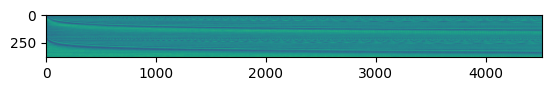

In [48]:
plt.imshow(encoded_light_curve[0,:,:].detach().numpy().T)
plt.show()

## Option 2: Only re-define the first Conv1 layer and reserve the rest as it is in pre-trained Whisper

In [49]:
# Load pre-trained whisper model
model = whisper.load_model(whisper_model_type).cuda()

print(
    f"Model is {'multilingual' if model.is_multilingual else 'English-only'} "
    f"and has {sum(np.prod(p.shape) for p in model.parameters()):,} parameters."
)

Model is multilingual and has 37,184,640 parameters.


In [54]:
# Adjust conv1 layer to ensure the output shape matches (n_ctx, n_mels)
model.encoder.conv1 = nn.Conv1d(
    in_channels=187,  # New input channels to match your input tensor
    out_channels=384,  # Adjust to match the positional embedding feature size
    kernel_size=3,  # Adjust this as needed
    stride=1,  # Adjust this as needed
    padding=1  # Adjust this as needed to maintain output size
)

model.encoder.register_buffer("positional_embedding", whisper.model.sinusoids(4512, 384))

model = model.to('cuda')
light_curve_reshaped_device = light_curve_reshaped.to('cuda')



# Pass the padded tensor to the encoder
encoded_data_2 = model.encoder(light_curve_reshaped_device)
print("Encoded data shape:", encoded_data_2.shape)

Encoded data shape: torch.Size([6, 4512, 384])


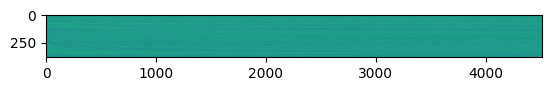

In [58]:
plt.imshow(encoded_data_2[0,:,:].cpu().detach().numpy().T)
plt.show()

## Option 3: Retain the pre-trained Whisper model and feed the astro data converted to audio file

In [ ]:
# SAMPLE_WAV = "/kaggle/input/astro-audios/kepler_12b.wav"
# audio, sampling_rate = torchaudio.load(SAMPLE_WAV)
# print(audio.shape)
# # audio = torchaudio.functional.resample(audio, orig_freq=sampling_rate, new_freq=16000)
# # print(audio.shape)

In [ ]:
# from transformers import WhisperFeatureExtractor

# feature_extractor = WhisperFeatureExtractor.from_pretrained("openai/whisper-tiny")
# arr = light_curve_mean.flatten() #whisper.pad_or_trim(light_curve_mean.flatten())
# # features = feature_extractor(arr, sampling_rate=16000).input_features

In [ ]:
# light_curve_mean.unsqueeze(dim=0).reshape(-1,187,6).shape

In [33]:
import torch.nn.functional as F

In [ ]:
# target_size

In [ ]:
# light_curve_tensor_flat.numel()

In [57]:
light_curve_tensor_padded.reshape(6,200,-1).shape

torch.Size([6, 200, 480])

In [45]:
light_curve_tensor_padded.permute(1,0).shape

torch.Size([96000, 6])

In [46]:
light_curve_tensor_flat.numel()

576000

In [69]:
light_curve_tensor_flat.shape

torch.Size([6, 576000])

In [64]:
target_size

576000

In [66]:
pad_size

574878

In [72]:
light_curve_tensor_padded_reshaped.shape

torch.Size([6, 1500, 384])

In [76]:
# Target shape based on positional_embedding
expected_n_mels, expected_n_ctx = n_ctx, n_mels
target_size = expected_n_mels * expected_n_ctx

# Flatten the tensor
light_curve_tensor_flat = light_curve_mean
print(len(light_curve_tensor_flat))

batch_size = 6
dimension = 187

# If the tensor needs padding
if light_curve_tensor_flat.shape[1] < target_size:
    # Pad the tensor to match the target size
    pad_size = target_size - light_curve_tensor_flat.shape[1]
    light_curve_tensor_flat = F.pad(light_curve_tensor_flat, (0, pad_size))

    
print(light_curve_tensor_flat.shape)
# Reshape to (batch_size, expected_n_mels, expected_n_ctx)
light_curve_tensor_padded = light_curve_tensor_flat.reshape(batch_size, -1).to('cuda')

light_curve_tensor_padded_reshaped = light_curve_tensor_padded.reshape(6,expected_n_mels, expected_n_ctx)



# Load the original model
model = whisper.load_model("tiny").cuda()

# Adjust conv1 layer to ensure the output shape matches (n_ctx, n_mels)
model.encoder.conv1 = nn.Conv1d(
    in_channels=expected_n_ctx,  # New input channels to match your input tensor
    out_channels=expected_n_mels,  # Adjust to match the positional embedding feature size
    kernel_size=3,  # Adjust this as needed
    stride=1,  # Adjust this as needed
    padding=1  # Adjust this as needed to maintain output size
).to('cuda')

model.encoder.conv1 = model.encoder.conv1.to('cuda')



# Pass the padded tensor to the encoder
encoded_data = model.encoder(light_curve_tensor_padded_reshaped.permute(0,2,1))
print("Encoded data shape:", encoded_data.shape)

6
torch.Size([6, 576000])


RuntimeError: Given groups=1, weight of size [384, 384, 3], expected input[6, 1500, 1500] to have 384 channels, but got 1500 channels instead

In [28]:
# Convert numpy array to torch tensor
light_curve_unshaped_tensor = torch.tensor(features) #torch.tensor(features[:5,:,:]).to('cuda') #torch.tensor(light_curve_unshaped, dtype=torch.float32)
light_curve_unshaped_tensor = light_curve_unshaped_tensor.to('cuda')
light_curve_mean_reshaped = light_curve_mean.unsqueeze(dim=0).reshape(-1,187,6)
light_curve_mean_reshaped = light_curve_mean_reshaped.to('cuda')
model = model.to('cuda')

# Pass the tensor to the model encoder
encoded_data = model.encoder(light_curve_mean_reshaped) #model.encoder(light_curve_unshaped_tensor)
encoded_data.shape

NameError: name 'features' is not defined

### Visualisation of input features and the output embeddings extracted from whisper encoder 

In [ ]:
features.shape

In [ ]:
input_features = features[0] #features[:,50,:75].T
plt.imshow(input_features[:,:20].T)
plt.title("Input feature visualition\n given to the model encoder")
plt.show()

In [ ]:
output_features = encoded_data[0,:,:].detach().cpu().T
plt.imshow(output_features)
plt.title("Output feature visualition\n extracted from the model encoder")
plt.show()

## Model training Loop 

In [ ]:
trainBSNN = SNN_model_thLR(in_channels=28*28, hidden_neurons= args['hidden_neurons'], out_channels=args['num_classes'], initial_thresh=3.0)
trainBSNN.to(args['device'])

args['weight_decay'] = 1e-1

# Define the parameter groups: one for thresholds and one for other parameters (with L2 regularization)
# optimizer = torch.optim.AdamW([
#     {'params': [trainBSNN.v_threshold1, trainBSNN.v_threshold2], 'lr': args['lr_threshold'], 'weight_decay': 0},  # No weight decay for thresholds
#     {'params': [param for name, param in trainBSNN.named_parameters() if 'v_threshold' not in name], 'lr': args['lr'], 'weight_decay': args['weight_decay']}  # Apply weight decay for other parameters
# ])

optimizer = torch.optim.Adam([
    {'params': [trainBSNN.v_threshold1, trainBSNN.v_threshold2], 'lr': args['lr_threshold']},  # No weight decay for thresholds
    {'params': [param for name, param in trainBSNN.named_parameters() if 'v_threshold' not in name], 'lr': args['lr']}  # Apply weight decay for other parameters
])

# Use the custom lr scheduler
scheduler = lr_scheduler.LambdaLR(optimizer, lr_lambda)
scheduler_spTh = lr_scheduler.LambdaLR(optimizer, lr_lambda_spTh)

# Use Latency Encoder
encoder = encoding.PoissonEncoder()  

start_time = time.time()

# Initialize lists to track spike and voltage activity
spike_list_layer1 = []
v_list_layer1 = []
spike_list_layer2 = []
v_list_layer2 = []

loss_train_arr = []
loss_valid_arr = []

loss_min = np.inf
acc_max = -np.inf

for epoch in range(args['start_epoch'], args['epochs']):

    trainBSNN.train()

    train_acc = 0
    val_acc = 0
    loss_train = 0
    loss_valid = 0
    train_samples = 0
    val_samples = 0
    running_train_loss = 0
    running_eval_loss = 0

    for train_batch_idx, (img, label) in enumerate(train_loader):

        # Clear gradients for the optimizer before backward pass
        optimizer.zero_grad()
        
        label.apply_(label_map.get)
        
        img = img.to(args['device'])
        label = label.to(args['device'])
        label_onehot = F.one_hot(label, args['num_classes']).float()

        out_fr = 0.
        
        for t in range(args['T']):
            encoded_img = encoder(img)
            x = torch.flatten(encoded_img, start_dim=1)  # Flatten input image
            out_fr += trainBSNN(x)

        out_fr = out_fr / args['T']
        train_loss_step = F.mse_loss(out_fr, label_onehot)  # MSE Loss

        # # Accumulate the L2 regularization for parameters except the thresholds
        # l2_reg = 0
        # for name, param in trainBSNN.named_parameters():
        #     if 'v_threshold' not in name:
        #         l2_reg += torch.norm(param, 2)  # L2 regularization term

        # Add L2 regularization to the loss
        total_loss = train_loss_step #+ args['weight_decay'] * l2_reg

        loss_train += float(total_loss)
        total_loss.backward()
        
        optimizer.step()

        # Clamp thresholds to ensure they are positive
        # with torch.no_grad():
        #     trainBSNN.v_threshold1.clamp_(min=0)
        #     trainBSNN.v_threshold2.clamp_(min=0)

        train_samples += label.numel()
        train_acc += (out_fr.argmax(1) == label).float().sum().item()

        # Reset the network's state (clear memory in neurons)
        functional.reset_net(trainBSNN)

        running_train_loss += float(total_loss.item())

    lr_print = optimizer.param_groups[1]["lr"]
    lr_th_print = optimizer.param_groups[0]["lr"]

    # Step the scheduler
    scheduler_spTh.step()  # Slower decay rate for thresholds
    scheduler.step()  # Regular decay rate for other parameters

    # Evaluation loop
    trainBSNN.eval()
    with torch.no_grad():

        for eval_batch_idx, (img, label) in enumerate(val_loader):
            
            label.apply_(label_map.get)
            
            img = img.to(args['device'])
            label = label.to(args['device'])
            label_onehot = F.one_hot(label, args['num_classes']).float()

            out_fr_eval = 0.

            for t in range(args['T']):
                encoded_img = encoder(img)
                x = torch.flatten(encoded_img, start_dim=1)  # Flatten input image
                out_fr_eval += trainBSNN(x)

            out_fr_eval = out_fr_eval / args['T']
            validation_loss_step = F.mse_loss(out_fr_eval, label_onehot)  # MSE Loss for validation
            loss_valid += float(validation_loss_step)
            
            val_samples += label.numel()
            val_acc += (out_fr_eval.argmax(1) == label).float().sum().item()

            # Reset the network's state (clear memory in neurons)
            functional.reset_net(trainBSNN)
            
            running_eval_loss += float(validation_loss_step.item())

    loss_train /= len(train_loader)
    loss_valid /= len(val_loader)

    loss_train_arr.append(loss_train)
    loss_valid_arr.append(loss_valid)

    print('Epoch: {} Train Loss: {:.4f} Validation Loss: {:.4f} Train Accuracy: {:.4f}% Val Accuracy: {:.4f}% LR: {:.4f} LR_th: {:.4f} Spike Thresh: {}'.format(
        epoch, loss_train, loss_valid, train_acc/train_samples*100, val_acc/val_samples*100, lr_print, lr_th_print, (trainBSNN.v_threshold1.item(), trainBSNN.v_threshold2.item())))

    # Save model checkpoint if validation accuracy improves
    if acc_max < val_acc / val_samples:
        acc_max = val_acc / val_samples
        torch.save(trainBSNN.state_dict(), 'chckpt_MSE_tau=_{}_numCls={}_numNeur={}_epoch_{}.pth'.format((trainBSNN.v_threshold1.item(), trainBSNN.v_threshold2.item()), args['num_classes'], args['hidden_neurons'], epoch))
        print("\nMaximum Validation Accuracy of {:.4f}% at epoch {}".format(acc_max, epoch))
        print("Model Saved\n")

end_time = time.time()
print('Total training time: {:.4f}'.format(end_time-start_time))